# EDA — Review Insights / Semana 1

**Objetivo:** entender el dataset antes de construir el pipeline de Semana 2.  
**Negocios:** IDA Restaurant Bar (target) + El Mesón de Gauss, Mítica, Vittorio Ristorante (competidores).  
**Datos:** Google Maps reviews scrapeadas con Apify. Período: Oct 2025 – Abr 2026.

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

## 1. Carga y merge

In [12]:
with open('../data/sample/IDA_reviews_sample.json', encoding='utf-8') as f:
    ida_raw = json.load(f)

with open('../data/sample/competitors_reviews_sample.json', encoding='utf-8') as f:
    comp_raw = json.load(f)

df = pd.DataFrame(ida_raw + comp_raw)

# Normalizar
df['business'] = df['title']
df['is_target'] = df['business'] == 'IDA Restaurant Bar'
df['has_text'] = df['text'].notna() & (df['text'].str.strip() != '')
df['text_len'] = df['text'].str.len().fillna(0).astype(int)
df['published_at'] = pd.to_datetime(df['publishedAtDate'], utc=True, errors='coerce')
df['month'] = df['published_at'].dt.to_period('M')

print(f'Total reviews: {len(df)}')
print(f'Con texto:     {df.has_text.sum()} ({df.has_text.mean():.0%})')
print(f'Solo rating:   {(~df.has_text).sum()}')
df.groupby('business')[['stars','has_text']].agg({'stars':'count','has_text':'sum'}).rename(columns={'stars':'total','has_text':'con_texto'})

Total reviews: 250
Con texto:     156 (62%)
Solo rating:   94


C:\Users\Joaquin Ferrer\AppData\Local\Temp\ipykernel_19376\2911195942.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['published_at'].dt.to_period('M')


,total,con_texto
business,,
El Mesón de Gauss,50,30
IDA Restaurant Bar,100,53
Mitica,50,40
Vittorio Ristorante,50,33


## 2. Distribución de ratings por negocio

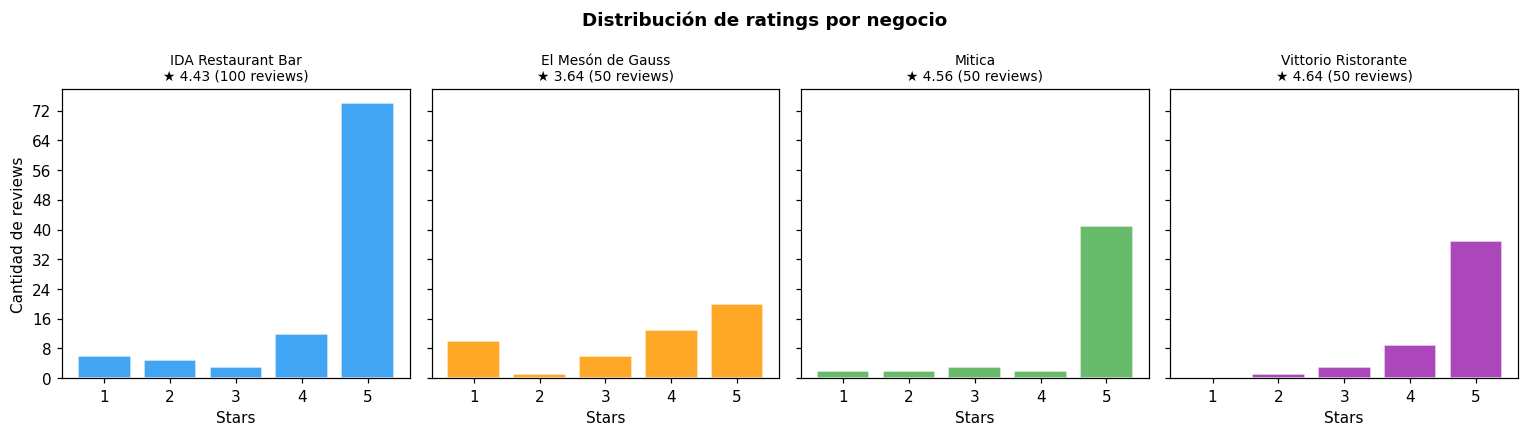

In [13]:
businesses = ['IDA Restaurant Bar', 'El Mesón de Gauss', 'Mitica', 'Vittorio Ristorante']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle('Distribución de ratings por negocio', fontsize=12, fontweight='bold')

for ax, biz, color in zip(axes, businesses, colors):
    sub = df[df['business'] == biz]
    counts = sub['stars'].value_counts().reindex([1,2,3,4,5], fill_value=0)
    avg = sub['stars'].mean()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{biz}\n★ {avg:.2f} ({len(sub)} reviews)', fontsize=9)
    ax.set_xlabel('Stars')
    ax.set_xticks([1,2,3,4,5])
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[0].set_ylabel('Cantidad de reviews')
plt.tight_layout()
plt.savefig('../outputs/rating_distribution.png', bbox_inches='tight')
plt.show()

## 3. Rating promedio — benchmark visual

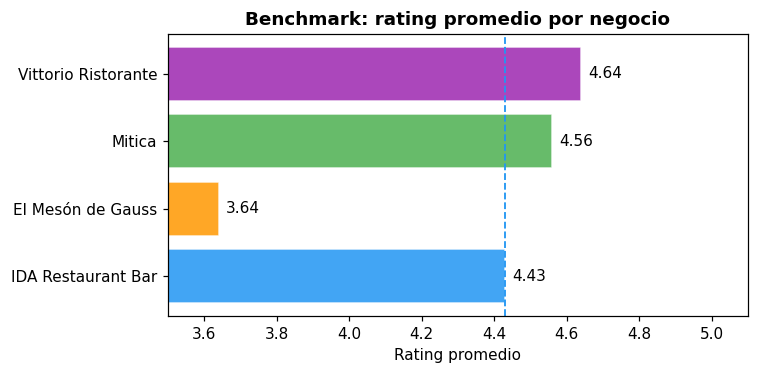

In [14]:
avg_ratings = df.groupby('business')['stars'].mean().reindex(businesses)

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(businesses, avg_ratings.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlim(3.5, 5.1)
ax.set_xlabel('Rating promedio')
ax.set_title('Benchmark: rating promedio por negocio', fontweight='bold')
ax.axvline(avg_ratings['IDA Restaurant Bar'], color='#2196F3', linestyle='--', linewidth=1.2, label='IDA')

for bar, val in zip(bars, avg_ratings.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/rating_benchmark.png', bbox_inches='tight')
plt.show()

## 4. Volumen de reviews en el tiempo

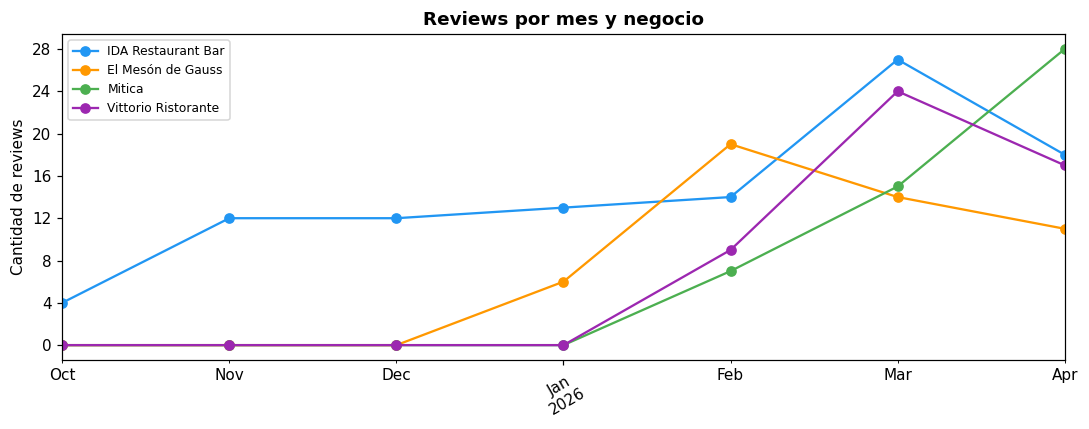

In [15]:
monthly = df.groupby(['month', 'business']).size().unstack(fill_value=0)
# Reordenar columnas
monthly = monthly.reindex(columns=[b for b in businesses if b in monthly.columns])

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker='o', linewidth=1.5, color=colors[:len(monthly.columns)])
ax.set_title('Reviews por mes y negocio', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de reviews')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/reviews_monthly.png', bbox_inches='tight')
plt.show()

## 5. Largo de texto — calibración para tokens del prompt

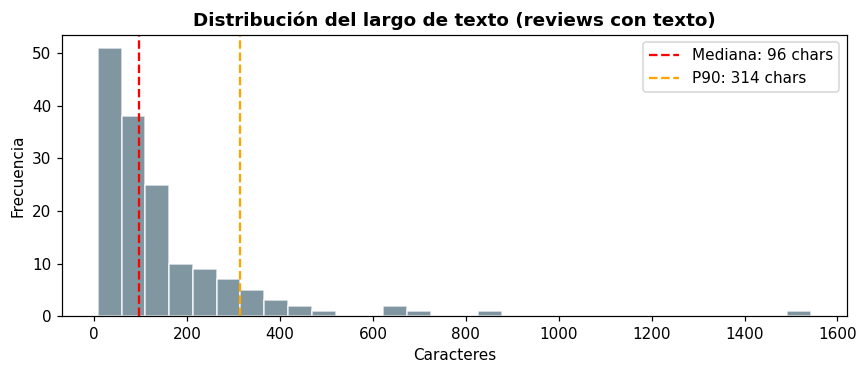

Reviews con texto: 156
count     156
mean      148
std       177
min         8
25%        53
50%        96
75%       170
max      1543


In [16]:
text_df = df[df['has_text']].copy()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(text_df['text_len'], bins=30, color='#607D8B', alpha=0.8, edgecolor='white')
ax.axvline(text_df['text_len'].median(), color='red', linestyle='--', label=f'Mediana: {text_df["text_len"].median():.0f} chars')
ax.axvline(text_df['text_len'].quantile(0.9), color='orange', linestyle='--', label=f'P90: {text_df["text_len"].quantile(0.9):.0f} chars')
ax.set_title('Distribución del largo de texto (reviews con texto)', fontweight='bold')
ax.set_xlabel('Caracteres')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/text_length.png', bbox_inches='tight')
plt.show()

print(f"Reviews con texto: {len(text_df)}")
print(text_df['text_len'].describe().round(0).astype(int).to_string())

## 6. reviewContext — campos más frecuentes

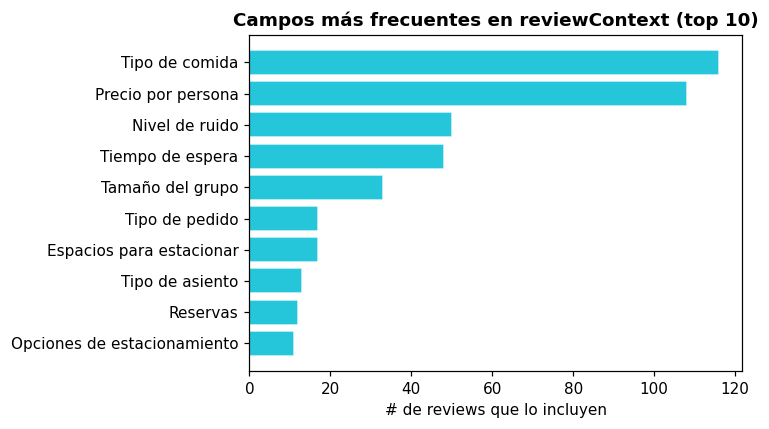

,campo,frecuencia
0,Tipo de comida,116
1,Precio por persona,108
2,Nivel de ruido,50
3,Tiempo de espera,48
4,Tamaño del grupo,33
5,Tipo de pedido,17
6,Espacios para estacionar,17
7,Tipo de asiento,13
8,Reservas,12
9,Opciones de estacionamiento,11


In [17]:
ctx_keys = Counter()
for ctx in df['reviewContext'].dropna():
    if isinstance(ctx, dict):
        ctx_keys.update(ctx.keys())

ctx_df = pd.DataFrame(ctx_keys.most_common(10), columns=['campo', 'frecuencia'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ctx_df['campo'][::-1], ctx_df['frecuencia'][::-1], color='#00BCD4', alpha=0.85, edgecolor='white')
ax.set_title('Campos más frecuentes en reviewContext (top 10)', fontweight='bold')
ax.set_xlabel('# de reviews que lo incluyen')
plt.tight_layout()
plt.savefig('../outputs/context_fields.png', bbox_inches='tight')
plt.show()

ctx_df

## 7. Sample de reviews negativas de IDA (1-2 estrellas)

In [18]:
negative_ida = df[
    (df['business'] == 'IDA Restaurant Bar') &
    (df['stars'] <= 2) &
    df['has_text']
][['stars', 'text', 'publishedAtDate']].sort_values('publishedAtDate', ascending=False)

print(f'Reviews negativas con texto (IDA): {len(negative_ida)}')
for _, row in negative_ida.iterrows():
    print(f"\n★{'☆'*(5-row.stars)} | {str(row.publishedAtDate)[:10]}")
    print(row.text)

Reviews negativas con texto (IDA): 8

★☆☆☆ | 2026-03-24
No fuimos bien atendidos, nos tomaron la mitad del pedido, al no haber opciones de platos principales vegetarianos, la moza consultó y no ofrecieron opciones. Luego sentido de seguir tomando el pedido.

No hay platos principales Vegetarianos ni Veganos.

Carta reducida en comparación a épocas anteriores.

Las guarniciones estaban frías.

★☆☆☆ | 2026-03-08
Fuimos anoche y realmente muy decepcionado
Desde la mesa,  a la moza con la mini copa de bienvenida era tan Poco que era mejor que no sirvieran nada
La comida 4 puntos , la entraña incomible la reemplazo por otra comida , tardó tanto que no la comimos
Nos regalaron 3

★☆☆☆☆ | 2026-02-16
La comida más o menos y lo peor el servicio dejó muchísimo que desear. Tuvieron un accidente con un plato de bondiola y nos empaparon con el jugo de la cocción. Nadie se acercó a pedir disculpas ni a ofrecer una solución. Pagamos el total de la cuenta casi 100mil pesos  y nos fuimos muy decepciona

## 8. Sample de reviews negativas de El Mesón de Gauss

In [19]:
negative_meson = df[
    (df['business'] == 'El Mesón de Gauss') &
    (df['stars'] <= 2) &
    df['has_text']
][['stars', 'text', 'publishedAtDate']].sort_values('publishedAtDate', ascending=False)

print(f'Reviews negativas con texto (El Mesón): {len(negative_meson)}')
for _, row in negative_meson.iterrows():
    print(f"\n★{'☆'*(5-row.stars)} | {str(row.publishedAtDate)[:10]}")
    print(row.text)

Reviews negativas con texto (El Mesón): 11

★☆☆☆☆ | 2026-04-23
Ofrecieron la carta
Y no tienen nada, un desastre!

★☆☆☆ | 2026-04-14
Una pena que un lugar tan lindo, tenga mala atención. La moza muy amable pero se olvidaron de comandar el pedido, por lo cual estuvimos 1h esperando el almuerzo. Una pena

★☆☆☆☆ | 2026-04-13
Un horror,fui con mi hija y mi nieta a merendar,dos cafe con leche,tostado tostadas fit,y criollitos,en la mitad de la merienda,mi hija toma un sorbo del cafe y se saca de la boca una mosca muerta!!!!! Q asco,nos cobraron como si fuera de lujo,se ve q ni lavan ni miran las tazas!! Vomito del asco ,nunca mas!!!

★☆☆☆☆ | 2026-03-09
La verdad totalmente decepcionado, porque fuimos recomendados porque supuestamente se come muy bien. Mucha demora entre el pedido hasta la llegada de los platos.

★☆☆☆☆ | 2026-02-26
Medialunas y criollos de mala calidad. Café de mala calidad. Asientos y mesas desniveladas. No te pueden ofrecer un desayuno completo por 9 mil pesos c/u , con es

## 9. Conclusiones para Semana 2

**Dataset:**
- 250 reviews totales (100 IDA + 50 por cada competidor). Período: Oct 2025 – Abr 2026.
- **156/250 tienen texto** (62%). Las 94 restantes son solo rating — se procesan por aggregation pero no por LLM.
- IDA tiene 53 reviews con texto. Suficiente para clasificación + eval manual de 30-50.

**Ratings:**
- IDA está bien posicionado en rating crudo — ver gráfico benchmark para comparar vs. competidores.
- El Mesón de Gauss tiene la mayor cantidad de reviews negativas (10 x 1★) → ángulo de venta: "mirá lo que dicen de tu competidor".

**Texto:**
- Mediana ~97 chars, P90 ~350 chars. Reviews cortas → prompt liviano, costo bajo de clasificación.
- Algunas reviews superan 1000 chars → necesitamos truncado en el cleaning step.

**reviewContext:**
- `Tipo de comida` y `Precio por persona` están en +100 reviews → features estructuradas útiles para segmentar insights (ej: "almuerzo vs. cena", "ticket bajo vs. alto").
- Incluirlos como columnas en la tabla `reviews_classified` — evaluar en DECISIONS.md.

**Para el pipeline de Semana 2:**
1. `ingestion`: leer ambos JSON con `encoding='utf-8'`, unificar en DataFrame, agregar `source_file`
2. `cleaning`: filtrar `has_text`, truncar a 1500 chars, normalizar `publishedAtDate`, extraer `meal_type` y `price_range` de `reviewContext`.
3. `classification`: clasificar las 156 reviews con texto. Estimado: ~$0.05-0.10 total con Gemini Flash.
4. `aggregation`: métricas sobre las 250 (rating stats) + clasificación sobre las 156 (topic breakdown).